In [8]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import pandas as pd
from utils.graph import dag_to_cpdag, dag_to_cpdag_pgmpy
from metrics.graph import compare_dags
from algorithms.ea_adj import *
from algorithms.ea import *
from utils.graph import dag_to_cpdag


In [9]:
import pickle

# subset = 'binaryManyRoots'
# subset = 'toySmall'
subset = 'jointpmf_grid'

# with open(f'old_results/results/ea_ies/{subset}.pkl', 'rb') as f:
    # results_ea = pickle.load(f)

# with open(f'old_results/results/ges/{subset}.pkl', 'rb') as f:
    # results_ges = pickle.load(f)

with open(f'old_results/results/hc/{subset}.pkl', 'rb') as f:
    results_hc = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'old_results/results/hc/jointpmf_grid.pkl'

In [10]:
r_idx = 1   # Replication index
d_idx = 0     # Dataset index
# viz = GraphVisualization(metadata=results_sub.metadata[0], results=results_sub.learned_dags[0])
# viz.visualize_network_labels(
# viz.compare_dags_with_labels()
# print(results_sub.bic_scores[0])
compare_dags(results_ea[r_idx].true_dags[d_idx], results_ea[r_idx].learned_dags[d_idx])
# print("EA BIC Score:", results_ea.bic_scores[d_idx])

NameError: name 'results_ea' is not defined

In [24]:
print("EA BIC Score:", results_ea[r_idx].bic_scores[d_idx])

EA BIC Score: -100286.47422331471


In [25]:
results_rep = {}
for _ in range(len(results_ea[r_idx].learned_dags)):
    cpdag = dag_to_cpdag(results_ea[r_idx].learned_dags[_])
    results_rep[_] = compare_dags(results_ea[r_idx].true_dags[_], cpdag)

# results_rep

In [26]:
# results_rep

In [27]:
results_rep = {}
for _ in range(len(results_ea[r_idx].learned_dags)):
    cpdag = dag_to_cpdag(results_ea[r_idx].learned_dags[_])
    results_rep[_] = compare_dags(results_ea[r_idx].true_dags[_], cpdag)

In [28]:
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)

# Load the data
# df = pd.read_csv(f"data/syntheticToy/{subset}/Data_Graph_{d_idx}.csv")
df = pd.read_csv(f"data/syntheticBinary/{subset}/Data_Graph_{d_idx}.csv")

rep_ea = {}
# Enumerate Results over replications 
for _ in range(len(results_ea)):        
    # Calculate the BIC score for cpdag_nx
    bic = BIC(df)
    dag_score = bic.score(results_ea[_].learned_dags[d_idx])
    cpdag = dag_to_cpdag(results_ea[_].learned_dags[d_idx])
    cpdag_score = bic.score(cpdag)
    print("--- Replication", _ , "---")
    print("BIC Score for cpdag:", cpdag_score)
    print("BIC Score for dag:", dag_score)

    rep_ea[_] = {}
    rep_ea[_]["cpdag"] = compare_dags(results_ea[_].true_dags[d_idx], cpdag)
    rep_ea[_]["dag"] = compare_dags(results_ea[_].true_dags[d_idx], results_ea[_].learned_dags[d_idx])
    

--- Replication 0 ---
BIC Score for cpdag: -100289.24389769735
BIC Score for dag: -100289.24389769735
--- Replication 1 ---
BIC Score for cpdag: -100286.47422331471
BIC Score for dag: -100286.47422331471
--- Replication 2 ---
BIC Score for cpdag: -100289.24389769735
BIC Score for dag: -100289.24389769735
--- Replication 3 ---
BIC Score for cpdag: -100317.79089388867
BIC Score for dag: -100317.79089388867
--- Replication 4 ---
BIC Score for cpdag: -100304.497119867
BIC Score for dag: -100304.497119867
--- Replication 5 ---
BIC Score for cpdag: -100289.24389769735
BIC Score for dag: -100289.24389769735
--- Replication 6 ---
BIC Score for cpdag: -100289.24389769735
BIC Score for dag: -100289.24389769735
--- Replication 7 ---
BIC Score for cpdag: -100286.47422331471
BIC Score for dag: -100286.47422331471
--- Replication 8 ---
BIC Score for cpdag: -100289.24389769735
BIC Score for dag: -100289.24389769735
--- Replication 9 ---
BIC Score for cpdag: -100289.24389769735
BIC Score for dag: -100

In [29]:
# rep_ea

In [30]:
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)

# Load the data
# df = pd.read_csv(f"data/syntheticToy/{subset}/Data_Graph_{d_idx}.csv")
df = pd.read_csv(f"data/syntheticBinary/{subset}/Data_Graph_{d_idx}.csv")

rep_hc = {}
# Enumerate Results over replications 
for _ in range(len(results_hc)):        
    # Calculate the BIC score for cpdag_nx
    bic = BIC(df)
    dag_score = bic.score(results_hc[_].learned_dags[d_idx])
    cpdag = dag_to_cpdag(results_hc[_].learned_dags[d_idx])
    cpdag_score = bic.score(cpdag)
    print("--- Replication", _ , "---")
    print("BIC Score for cpdag:", cpdag_score)
    print("BIC Score for dag:", dag_score)
    
    rep_hc[_] = {}
    rep_hc[_]["cpdag"] = compare_dags(results_hc[_].true_dags[d_idx], cpdag)
    rep_hc[_]["dag"] = compare_dags(results_hc[_].true_dags[d_idx], results_hc[_].learned_dags[d_idx])

--- Replication 0 ---
BIC Score for cpdag: -96056.2668890612
BIC Score for dag: -100327.25549501808
--- Replication 1 ---
BIC Score for cpdag: -96056.2668890612
BIC Score for dag: -100327.25549501808
--- Replication 2 ---
BIC Score for cpdag: -95973.17058161934
BIC Score for dag: -100310.30168390209
--- Replication 3 ---
BIC Score for cpdag: -95973.17058161934
BIC Score for dag: -100310.30168390209
--- Replication 4 ---
BIC Score for cpdag: -96193.40749329644
BIC Score for dag: -100339.33012412154
--- Replication 5 ---
BIC Score for cpdag: -96056.2668890612
BIC Score for dag: -100327.25549501808
--- Replication 6 ---
BIC Score for cpdag: -95973.17058161934
BIC Score for dag: -100310.30168390209
--- Replication 7 ---
BIC Score for cpdag: -95973.17058161934
BIC Score for dag: -100310.30168390209
--- Replication 8 ---
BIC Score for cpdag: -96056.2668890612
BIC Score for dag: -100327.25549501808
--- Replication 9 ---
BIC Score for cpdag: -96056.2668890612
BIC Score for dag: -100327.2554950

In [31]:
from utils.plotting import compare_dags_with_labels

True Graph
[(0, 3), (0, 4), (0, 6), (0, 8), (0, 10), (0, 11), (0, 12), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 9), (2, 12), (4, 13), (1, 5), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (7, 14), (7, 15), (9, 13), (9, 15), (12, 14)]
Learned Graph
[('0', '12'), ('0', '3'), ('0', '6'), ('0', '4'), ('0', '10'), ('0', '11'), ('12', '14'), ('4', '13'), ('1', '0'), ('1', '10'), ('1', '11'), ('1', '7'), ('1', '2'), ('1', '5'), ('1', '9'), ('7', '14'), ('7', '1'), ('7', '15'), ('7', '2'), ('7', '9'), ('2', '12'), ('2', '3'), ('2', '6'), ('2', '4'), ('2', '1'), ('2', '7'), ('2', '5'), ('2', '9'), ('5', '1'), ('5', '2'), ('5', '9'), ('9', '13'), ('9', '1'), ('9', '7'), ('9', '2'), ('9', '5'), ('9', '15'), ('15', '7'), ('15', '9'), ('8', '0')]

✅ Correct edges: [(0, 3), (0, 4), (0, 6), (0, 10), (0, 11), (0, 12), (1, 5), (1, 7), (1, 9), (1, 10), (1, 11), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 9), (2, 12), (4, 13), (7, 14), (7, 15), (9, 13), (9, 15), (12, 14)]
🔄 Wrong-direction edges: [(5, 1),

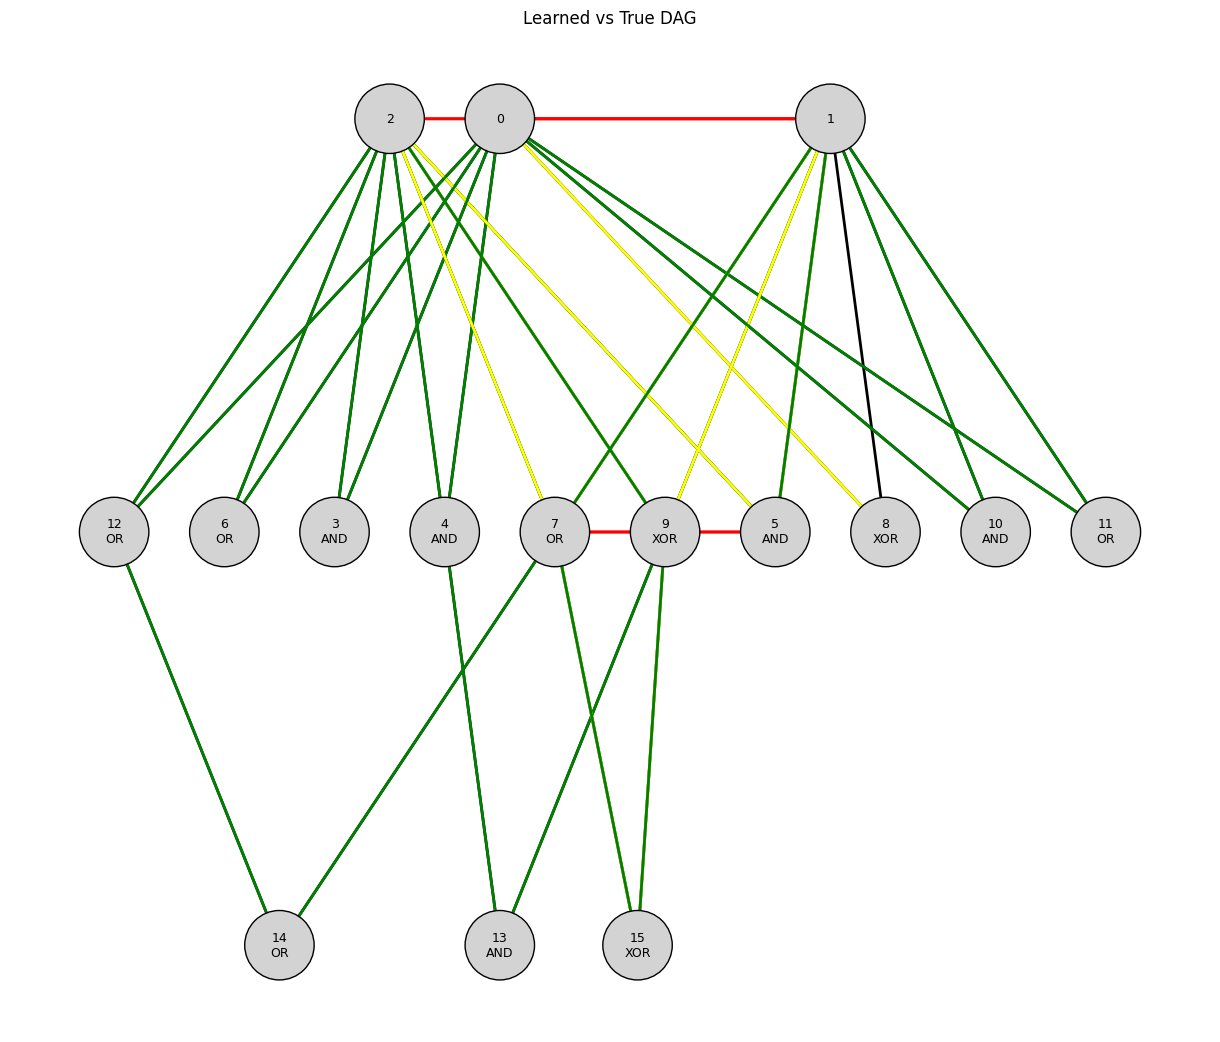

{'correct': {(0, 3),
  (0, 4),
  (0, 6),
  (0, 10),
  (0, 11),
  (0, 12),
  (1, 5),
  (1, 7),
  (1, 9),
  (1, 10),
  (1, 11),
  (2, 3),
  (2, 4),
  (2, 5),
  (2, 6),
  (2, 7),
  (2, 9),
  (2, 12),
  (4, 13),
  (7, 14),
  (7, 15),
  (9, 13),
  (9, 15),
  (12, 14)},
 'wrong_dir': {(5, 1),
  (5, 2),
  (7, 1),
  (7, 2),
  (8, 0),
  (9, 1),
  (9, 2),
  (15, 7),
  (15, 9)},
 'extra': {(1, 0), (1, 2), (2, 1), (5, 9), (7, 9), (9, 5), (9, 7)},
 'missing': {(0, 8), (1, 8)},
 'precision': 0.6,
 'recall': 0.9230769230769231,
 'f1': 0.7272727272727274}

In [32]:
r_idx = 5
# compare_dags_with_labels(results_hc[r_idx].true_dags[d_idx], results_hc[r_idx].learned_dags[d_idx], results_hc[r_idx].metadata[d_idx], title="Learned vs True DAG")

compare_dags_with_labels(results_hc[r_idx].true_dags[d_idx], dag_to_cpdag(results_hc[r_idx].learned_dags[d_idx]), results_hc[r_idx].metadata[d_idx], title="Learned vs True DAG")

In [16]:
results_ea[r_idx].metadata[d_idx]

,Combs,Type
0,"[1, 2, 3]",AND
1,"[0, 1, 4]",XOR
2,"[1, 2, 5]",XOR
3,"[0, 1, 6]",AND
4,"[0, 2, 7]",XOR
5,"[0, 1, 8]",AND
6,"[0, 2, 9]",XOR
7,"[1, 2, 10]",XOR
8,"[9, 10, 11]",OR
9,"[5, 7, 12]",OR


True Graph
[(0, 3), (0, 4), (0, 6), (0, 8), (0, 10), (0, 11), (0, 12), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 9), (2, 12), (4, 13), (1, 5), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (7, 14), (7, 15), (9, 13), (9, 15), (12, 14)]
Learned Graph
[('0', '8'), ('0', '11'), ('0', '10'), ('0', '4'), ('0', '3'), ('0', '12'), ('0', '6'), ('1', '8'), ('1', '9'), ('1', '5'), ('1', '11'), ('1', '10'), ('1', '7'), ('2', '9'), ('2', '5'), ('2', '4'), ('2', '3'), ('2', '12'), ('2', '7'), ('2', '6'), ('4', '13'), ('7', '15'), ('7', '14'), ('9', '15'), ('9', '13'), ('12', '14')]

✅ Correct edges: [(0, 3), (0, 4), (0, 6), (0, 8), (0, 10), (0, 11), (0, 12), (1, 5), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 9), (2, 12), (4, 13), (7, 14), (7, 15), (9, 13), (9, 15), (12, 14)]
🔄 Wrong-direction edges: []
⚠️ Extra edges: []
❌ Missing edges: []

📊 Precision: 1.00, Recall: 1.00, F1: 1.00


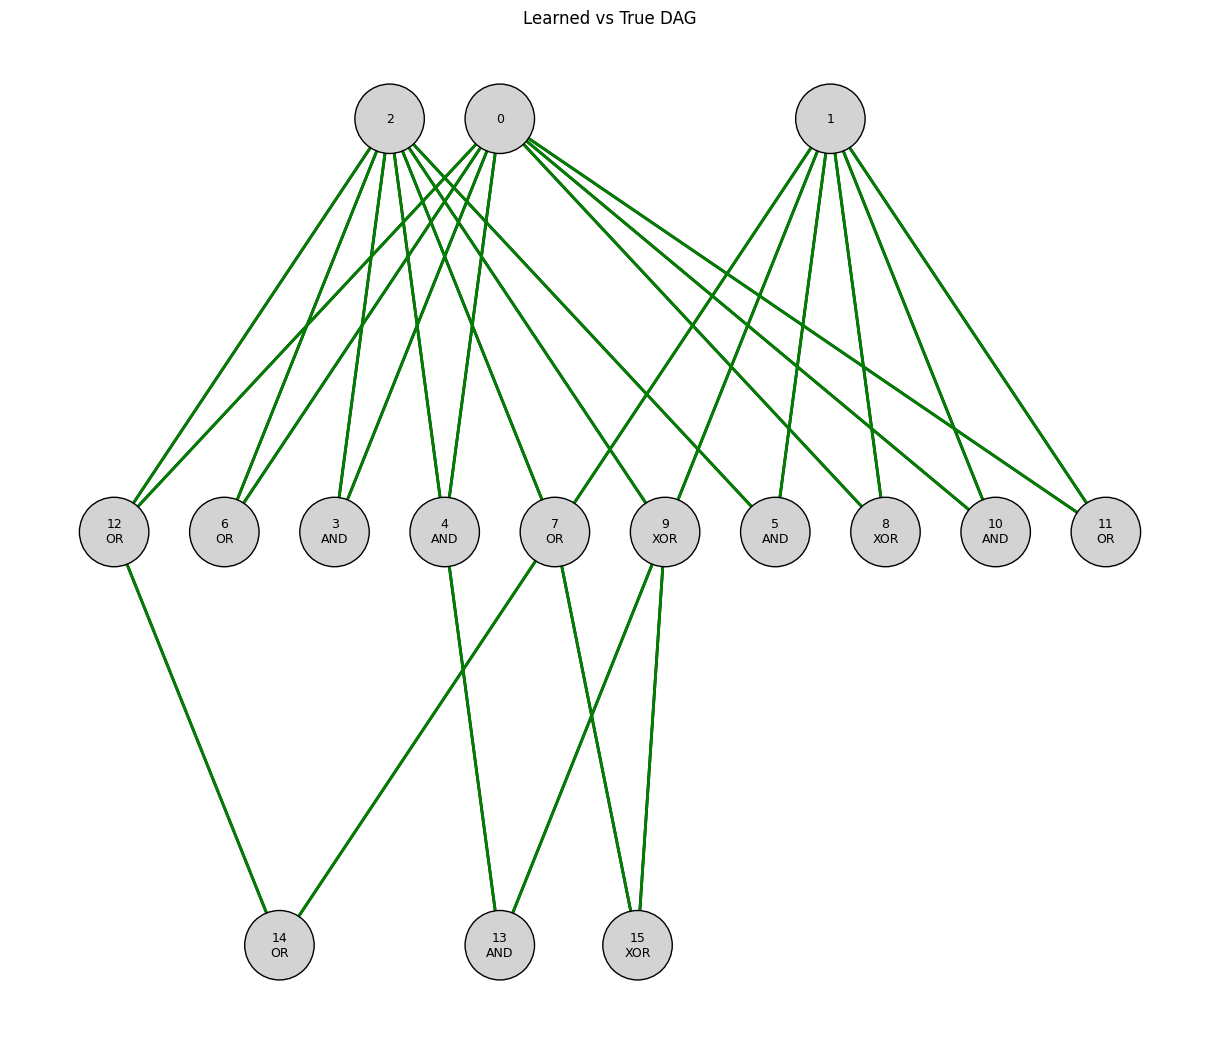

{'correct': {(0, 3),
  (0, 4),
  (0, 6),
  (0, 8),
  (0, 10),
  (0, 11),
  (0, 12),
  (1, 5),
  (1, 7),
  (1, 8),
  (1, 9),
  (1, 10),
  (1, 11),
  (2, 3),
  (2, 4),
  (2, 5),
  (2, 6),
  (2, 7),
  (2, 9),
  (2, 12),
  (4, 13),
  (7, 14),
  (7, 15),
  (9, 13),
  (9, 15),
  (12, 14)},
 'wrong_dir': set(),
 'extra': set(),
 'missing': set(),
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0}

In [33]:
compare_dags_with_labels(results_ea[r_idx].true_dags[d_idx], results_ea[r_idx].learned_dags[d_idx], results_ea[r_idx].metadata[d_idx], title="Learned vs True DAG")

In [ ]:
cpdag_nx.edges()

OutEdgeView([('0', '8'), ('0', '19'), ('0', '17'), ('0', '2'), ('19', '17'), ('17', '2'), ('2', '10'), ('2', '13'), ('1', '8'), ('1', '4'), ('1', '3'), ('1', '12'), ('1', '7'), ('4', '8'), ('4', '1'), ('4', '11'), ('4', '3'), ('4', '12'), ('4', '7'), ('3', '19'), ('3', '17'), ('3', '10'), ('3', '5'), ('3', '1'), ('3', '4'), ('3', '18'), ('3', '7'), ('12', '1'), ('12', '4'), ('12', '11'), ('10', '15'), ('18', '3'), ('5', '16'), ('5', '0'), ('11', '4'), ('11', '12'), ('6', '5'), ('6', '0'), ('6', '9'), ('6', '14'), ('9', '6'), ('7', '16'), ('7', '1'), ('7', '4'), ('7', '3'), ('14', '6')])

In [ ]:
def compare_dags_with_labels(true_graph,
                             learned_graph,
                             metadata=None,
                             title="Learned vs True DAG",
                             logic_map=None):
    import ast
    from collections import defaultdict
    import matplotlib.pyplot as plt
    import networkx as nx

    # --- Build type mapping from DF (optional) ---
    node_kind = defaultdict(set)
    if metadata is not None:
        for _, row in metadata.iterrows():
            comb = row["Combs"]
            if isinstance(comb, str):
                comb = ast.literal_eval(comb)
            kind = row["Type"]
            if len(comb) == 3:
                _, _, w = comb
                node_kind[w].add(kind)
            elif len(comb) == 2:
                _, v = comb
                node_kind[v].add(kind)

    # -------------------------- split learned into directed + undirected
    learned_directed = None
    learned_undirected = nx.Graph()

    if isinstance(learned_graph, (tuple, list)) and len(learned_graph) == 2:
        learned_directed, learned_undirected = learned_graph
        if learned_directed is None:
            learned_directed = nx.DiGraph()
        if learned_undirected is None:
            learned_undirected = nx.Graph()
    else:
        learned_directed = learned_graph

        # If learned_directed is a DiGraph encoding undirected edges as both directions:
        if isinstance(learned_directed, nx.DiGraph):
            for u, v, data in learned_directed.edges(data=True):
                # attribute-based undirected
                if data.get("kind") == "undirected":
                    learned_undirected.add_edge(u, v)

            # mutual edges (u->v and v->u) treated as undirected
            for u, v in list(learned_directed.edges()):
                if learned_directed.has_edge(v, u):
                    learned_undirected.add_edge(u, v)

            # remove undirected pairs from directed edge set to avoid double drawing/counting
            for u, v in learned_undirected.edges():
                if learned_directed.has_edge(u, v):
                    learned_directed.remove_edge(u, v)
                if learned_directed.has_edge(v, u):
                    learned_directed.remove_edge(v, u)

    # --- Print edges ---
    print("True Graph")
    print(list(true_graph.edges()))
    print("Learned (directed) Graph")
    print(list(learned_directed.edges()) if learned_directed is not None else [])
    print("Learned (undirected) edges")
    print(list(learned_undirected.edges()))

    # --- Convert true edges to int tuples ---
    true_set = {(int(u), int(v)) for u, v in true_graph.edges()}
    true_rev = {(v, u) for (u, v) in true_set}

    # Directed learned edges
    learned_dir_set = {(int(u), int(v)) for u, v in learned_directed.edges()} if learned_directed is not None else set()

    # Undirected learned edges as frozensets
    learned_undir_set = {frozenset((int(u), int(v))) for u, v in learned_undirected.edges()}

    # --- Compare (treat undirected as "matches either direction") ---
    correct_dir = learned_dir_set & true_set
    wrong_dir = learned_dir_set & true_rev
    extra_dir = learned_dir_set - (true_set | true_rev)

    correct_undir = {e for e in learned_undir_set if (tuple(e) in [])}  # unused placeholder

    correct_undir = set()
    extra_undir = set()
    for e in learned_undir_set:
        u, v = tuple(e)
        if (u, v) in true_set or (v, u) in true_set:
            correct_undir.add(e)
        else:
            extra_undir.add(e)

    # Missing = true edges not covered by directed correct OR by any undirected match
    covered_true = set(correct_dir)
    for e in correct_undir:
        u, v = tuple(e)
        if (u, v) in true_set:
            covered_true.add((u, v))
        if (v, u) in true_set:
            covered_true.add((v, u))
    missing = true_set - covered_true

    correct = correct_dir | {(min(u, v), max(u, v)) for (u, v) in correct_dir}  # just for printing
    print("\n✅ Correct directed edges:", sorted(correct_dir))
    print("🟩 Undirected edges (kept green):", sorted([tuple(sorted(e)) for e in correct_undir | extra_undir]))
    print("🔄 Wrong-direction edges:", sorted(wrong_dir))
    print("⚠️ Extra directed edges:", sorted(extra_dir))
    print("⚠️ Extra undirected edges:", sorted([tuple(sorted(e)) for e in extra_undir]))
    print("❌ Missing edges:", sorted(missing))

    # --- Precision / Recall / F1 (counts undirected matches as TP) ---
    tp = len(correct_dir) + len(correct_undir)
    fp = len(extra_dir) + len(wrong_dir) + len(extra_undir)
    fn = len(missing)

    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
    print(f"\n📊 Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

    # --- Edge colors for learned directed edges ---
    dir_edge_list = []
    dir_edge_colors = []
    for u, v in learned_dir_set:
        dir_edge_list.append((u, v))
        if (u, v) in correct_dir:
            dir_edge_colors.append("green")
        elif (u, v) in wrong_dir:
            dir_edge_colors.append("yellow")
        else:
            dir_edge_colors.append("red")

    # Undirected edges: always green
    undir_edge_list = [(int(u), int(v)) for u, v in learned_undirected.edges()]

    # --- Layout ---
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        pos = graphviz_layout(true_graph, prog="dot")
    except Exception:
        pos = nx.spring_layout(true_graph, seed=42)

    # --- Labels and Node Colors ---
    node_labels = {}
    node_colors = []
    for n in true_graph.nodes():
        lines = [str(n)]
        if logic_map and n in logic_map:
            lines.append(str(logic_map[n]))
        if node_kind and n in node_kind:
            lines.append("/".join(sorted(node_kind[n])))
        node_labels[n] = "\n".join(lines)

        kinds = node_kind.get(n, set())
        if "SRV" in kinds and "Pairwise" in kinds:
            node_colors.append("violet")
        elif "SRV" in kinds:
            node_colors.append("tomato")
        elif "Pairwise" in kinds:
            node_colors.append("skyblue")
        else:
            node_colors.append("lightgrey")

    # --- Draw ---
    plt.figure(figsize=(12, 10))

    # True DAG background
    nx.draw(true_graph, pos,
            node_color=node_colors,
            labels=node_labels,
            node_size=2500,
            edgecolors="black",
            arrows=False,
            width=2,
            font_size=9)

    # Learned undirected overlay (always green, no arrows)
    if undir_edge_list:
        nx.draw_networkx_edges(learned_undirected, pos,
                               edgelist=undir_edge_list,
                               edge_color="green",
                               arrows=False,
                               width=2)

    # Learned directed overlay
    if dir_edge_list:
        nx.draw_networkx_edges(learned_directed, pos,
                               edgelist=dir_edge_list,
                               edge_color=dir_edge_colors,
                               arrows=True,
                               width=2)

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return {
        "correct_directed": correct_dir,
        "correct_undirected": correct_undir,
        "wrong_dir": wrong_dir,
        "extra_directed": extra_dir,
        "extra_undirected": extra_undir,
        "missing": missing,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


True Graph
[(0, 3), (0, 5), (0, 6), (0, 8), (0, 17), (3, 4), (3, 10), (3, 17), (3, 18), (2, 3), (2, 10), (2, 13), (1, 4), (1, 7), (1, 8), (1, 12), (4, 7), (4, 11), (5, 6), (5, 16), (6, 9), (6, 14), (7, 16), (10, 15), (11, 12), (17, 19)]
Learned (directed) Graph
[('0', '8'), ('0', '19'), ('0', '17'), ('0', '2'), ('19', '17'), ('17', '2'), ('2', '10'), ('2', '13'), ('1', '8'), ('4', '8'), ('3', '19'), ('3', '17'), ('3', '10'), ('3', '5'), ('10', '15'), ('5', '16'), ('5', '0'), ('6', '5'), ('6', '0'), ('7', '16')]
Learned (undirected) edges
[('1', '4'), ('1', '3'), ('1', '12'), ('1', '7'), ('4', '11'), ('4', '3'), ('4', '12'), ('4', '7'), ('3', '18'), ('3', '7'), ('12', '11'), ('6', '9'), ('6', '14')]

✅ Correct directed edges: [(0, 8), (0, 17), (1, 8), (2, 10), (2, 13), (3, 10), (3, 17), (5, 16), (7, 16), (10, 15)]
🟩 Undirected edges (kept green): [(1, 3), (1, 4), (1, 7), (1, 12), (3, 4), (3, 7), (3, 18), (4, 7), (4, 11), (4, 12), (6, 9), (6, 14), (11, 12)]
🔄 Wrong-direction edges: [(5, 

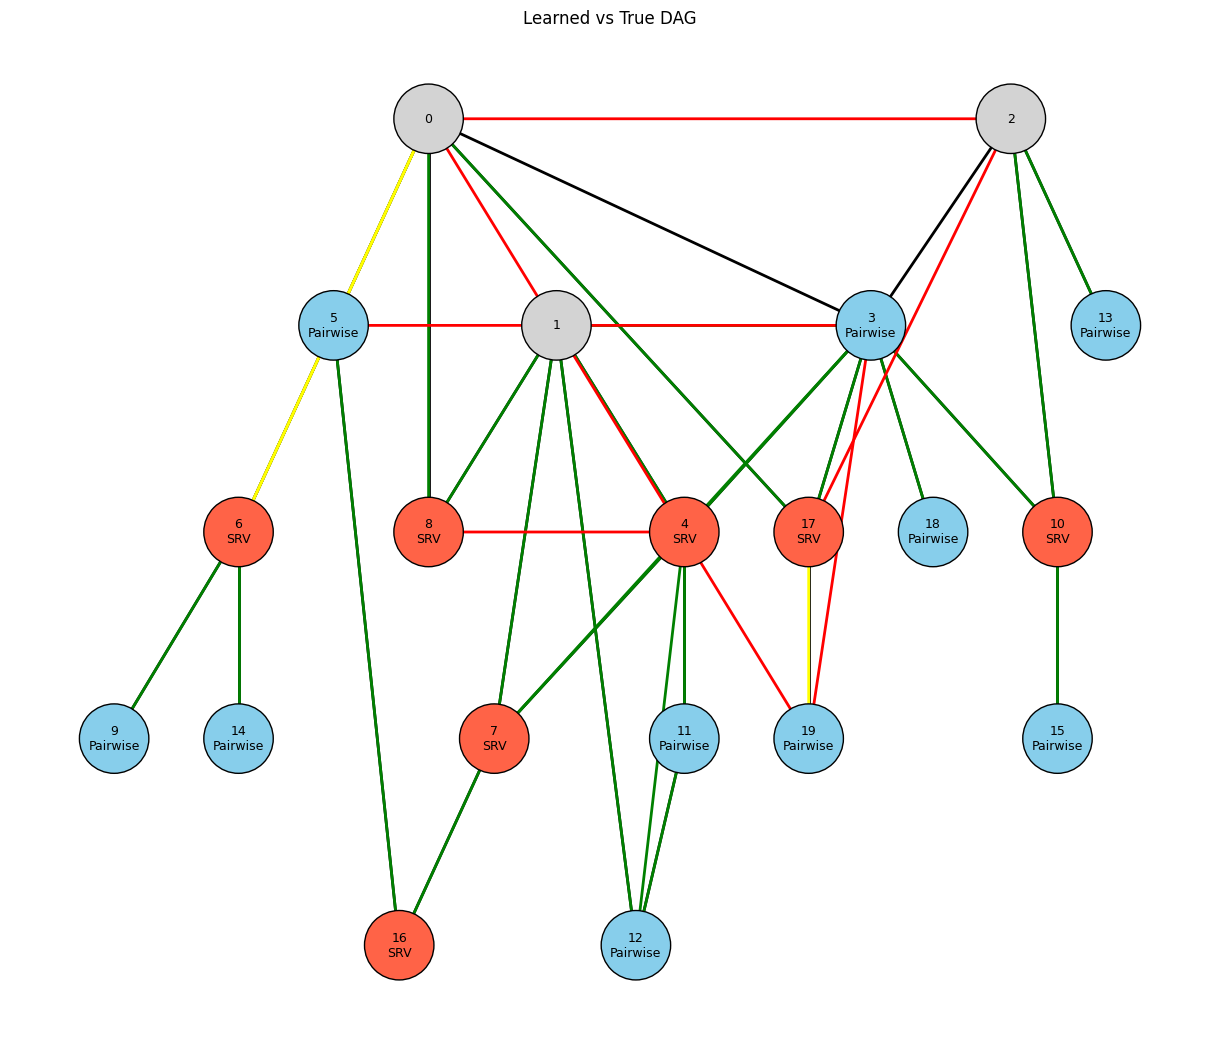

{'correct_directed': {(0, 8),
  (0, 17),
  (1, 8),
  (2, 10),
  (2, 13),
  (3, 10),
  (3, 17),
  (5, 16),
  (7, 16),
  (10, 15)},
 'correct_undirected': {frozenset({3, 4}),
  frozenset({6, 9}),
  frozenset({1, 4}),
  frozenset({1, 7}),
  frozenset({11, 12}),
  frozenset({6, 14}),
  frozenset({1, 12}),
  frozenset({4, 11}),
  frozenset({3, 18}),
  frozenset({4, 7})},
 'wrong_dir': {(5, 0), (6, 0), (6, 5), (19, 17)},
 'extra_directed': {(0, 2), (0, 19), (3, 5), (3, 19), (4, 8), (17, 2)},
 'extra_undirected': {frozenset({4, 12}),
  frozenset({1, 3}),
  frozenset({3, 7})},
 'missing': {(0, 3), (0, 5), (0, 6), (2, 3), (5, 6), (17, 19)},
 'precision': 0.6060606060606061,
 'recall': 0.7692307692307693,
 'f1': 0.6779661016949152}

In [ ]:
compare_dags_with_labels(results_sub.true_dags[0], cpdag_nx, results_sub.metadata[0], title="Learned vs True DAG")